<a href="https://colab.research.google.com/github/Zidane86-06/Data_Engineering_workshop/blob/main/Day2/Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully")
print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")

All libraries imported successfully
pandas version:2.2.2
sqlite3 version:2.6.0


In [25]:
df=pd.read_csv("student_performance.csv")
print(f"Dataset loaded:{df.shape[0]}students,{df.shape[1]}columns")
print(f"Columns:{df.columns}")
print("\nFirst 3 rows:")
df.head(3)

Dataset loaded:30students,13columns
Columns:Index(['student_id', 'name', 'age', 'gender', 'department', 'semester',
       'math_score', 'science_score', 'english_score', 'programming_score',
       'attendance_percentage', 'city', 'admission_year'],
      dtype='object')

First 3 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [ ]:
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print(f"Total students in the database:{count}")


Total students in the database:30


In [ ]:
def run_query(sql, description="student"):
  if description:
    print(f"{description}")

  result=pd.read_sql_query(sql, conn)
  return result
print("Helper function 'run_query' defined successfully")
print("Usage: run_quey(sql_string, description_label)")

Helper function 'run_query' defined successfully
Usage: run_quey(sql_string, description_label)


In [ ]:
query1="""SELECT * FROM students  Limit 10"""

result1=run_query(query1, "First 10 students")
result1

First 10 students


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023
5,1006,Meera Joshi,20,Female,Electronics,2,58,66,70,52,72,Pune,2023
6,1007,Kiran Kumar,21,Male,Civil,2,73,69,65,40,85,Bangalore,2023
7,1008,Divya Singh,19,Female,Computer Science,2,88,91,84,93,96,Lucknow,2023
8,1009,Rahul Mishra,20,Male,Mechanical,2,62,71,58,45,68,Varanasi,2023
9,1010,Ananya Das,19,Female,Computer Science,2,95,89,90,97,98,Kolkata,2023


In [ ]:
query2 = """SELECT name, department, math_score FROM students ORDER BY math_score DESC LIMIT 5"""

result2 = run_query(query2, "Top 5 Math Scores")
result2

Top 5 Math Scores


,name,department,math_score
0,Ananya Das,Computer Science,95
1,Tanvi Mehta,Computer Science,93
2,Arjun Nair,Computer Science,92
3,Akanksha Yadav,Computer Science,91
4,Swati Kulkarni,Computer Science,90


In [ ]:
query3="""Select name,math_score,science_score,programming_score,attendance_percentage FROM students where department="Computer Science" order by programming_score DESC"""
result3=run_query(query3,"Computer Science Students")
result3

Computer Science Students


,name,math_score,science_score,programming_score,attendance_percentage
0,Ananya Das,95,89,97,98
1,Tanvi Mehta,93,90,96,97
2,Arjun Nair,92,88,95,90
3,Akanksha Yadav,91,93,94,95
4,Divya Singh,88,91,93,96
5,Swati Kulkarni,90,87,92,94
6,Aarav Sharma,85,78,91,92
7,Amit Bose,86,82,89,91
8,Suresh Rao,83,86,88,88
9,Gaurav Shukla,84,79,87,87


In [ ]:
query4="""Select name , department, attendance_percentage from students where department!="Civil" and attendance_percentage>90 order by programming_score desc"""
result4=run_query(query4,"Students with attendance percentage greater than 90")
result4

Students with attendance percentage greater than 90


,name,department,attendance_percentage
0,Ananya Das,Computer Science,98
1,Tanvi Mehta,Computer Science,97
2,Akanksha Yadav,Computer Science,95
3,Divya Singh,Computer Science,96
4,Swati Kulkarni,Computer Science,94
5,Aarav Sharma,Computer Science,92
6,Amit Bose,Computer Science,91
7,Ritu Agarwal,Electronics,93
8,Kavya Nambiar,Mechanical,91
9,Sneha Reddy,Mechanical,95


In [ ]:
query5="""
Select
department,
count(*),
round(AVG(math_score),2) AS avg_math,
round(avg(science_score),2) AS avg_science,
round(avg(programming_score),2) AS avg_programming
from students
group by department
order by avg_math desc
"""
result5=run_query(query5, "Departmental Averages")
result5

Departmental Averages


,department,count(*),avg_math,avg_science,avg_programming
0,Computer Science,13,85.62,84.46,89.23
1,Mechanical,6,71.00,76.50,49.33
2,Electronics,6,71.00,74.17,61.50
3,Civil,5,63.40,66.60,40.60


In [ ]:
query6="""select gender,count(*) as num_students,round(avg(math_score),2) as avg_math, round(avg(science_score),2) as avg_science, round(avg(programming_score),2) as avg_programmming, round(avg(attendance_percentage),2)as avg_attendance from students group by gender"""
result6=run_query(query5)
result6

student


,department,count(*),avg_math,avg_science,avg_programming
0,Computer Science,13,85.62,84.46,89.23
1,Mechanical,6,71.00,76.50,49.33
2,Electronics,6,71.00,74.17,61.50
3,Civil,5,63.40,66.60,40.60


In [ ]:
query7="""select gender,count(*) as num_students,round(avg(math_score),2) as avg_math,round(avg(attendance_percentage),2) as avg_attendance from students group by gender"""
result7=run_query(query7, "Gender-wise Averages")
result7

Gender-wise Averages


,gender,num_students,avg_math,avg_attendance
0,Female,15,78.47,88.53
1,Male,15,73.67,80.47


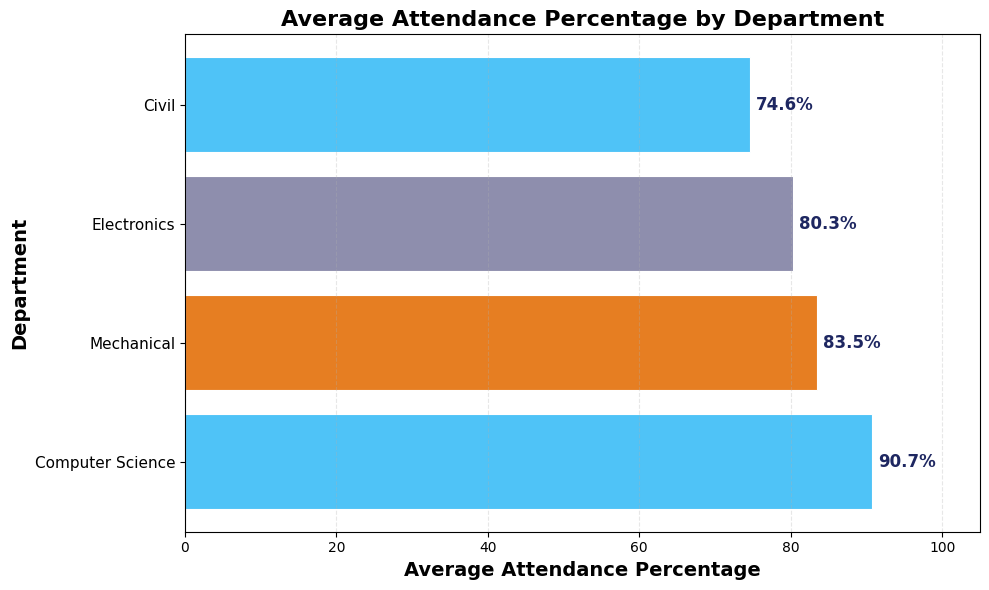

In [ ]:
chart1_sql="""
select department,Round(AVG(attendance_percentage),2) as avg_attendance
from students
group by department
order by avg_attendance desc
"""
chart1_data=pd.read_sql_query(chart1_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))
bar_colors=["#4FC3F7","#E67E22","#8E8EAD"]
bars=ax.barh(
    chart1_data["department"],
    chart1_data["avg_attendance"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8)
for bar in bars:
  width=bar.get_width()
  ax.text(
      width+0.8,
      bar.get_y()+bar.get_height()/2,
      f'{width:.1f}%',
      ha='left',va='center',
      fontsize=12,fontweight='bold',
      color='#1E2761'
      )
  ax.set_title('Average Attendance Percentage by Department',fontsize=16,fontweight='bold')
  ax.set_ylabel('Department',fontsize=14,fontweight='bold')
  ax.set_xlabel('Average Attendance Percentage',fontsize=14,fontweight='bold')
  ax.set_xlim(0,105)
  ax.tick_params(axis='y',labelsize=11)
  ax.grid(axis='x',linestyle='--',alpha=0.3)
plt.tight_layout()
plt.show()

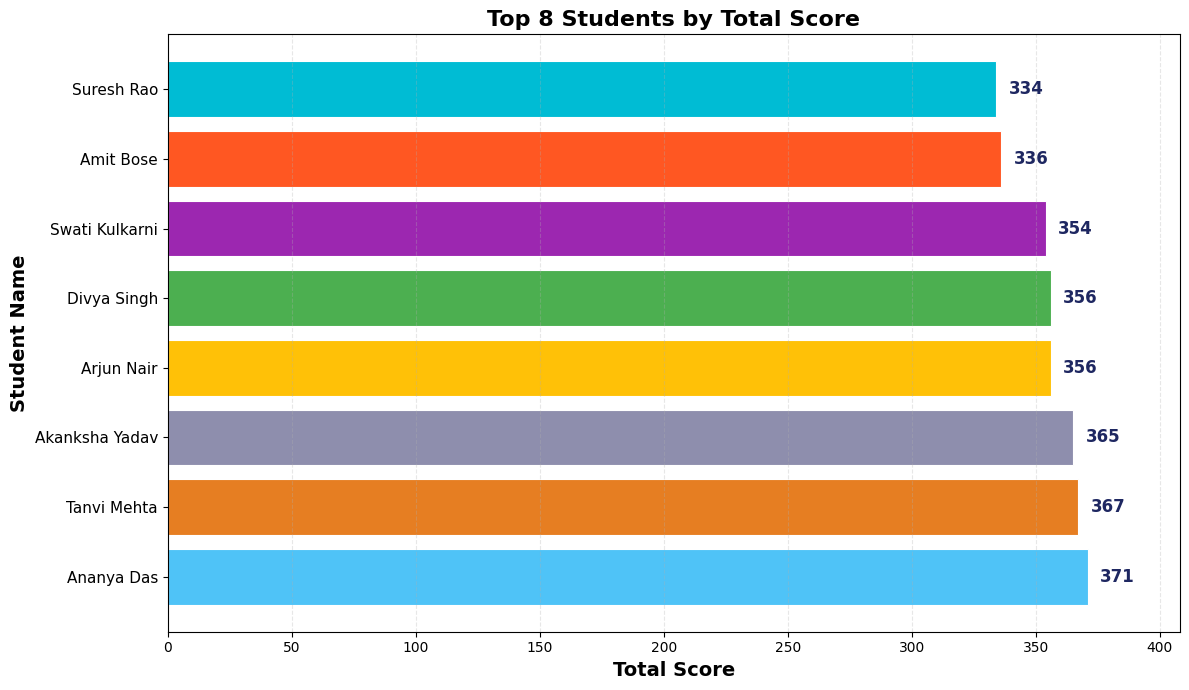

In [ ]:
chart_sql = """
SELECT
  name,
  (math_score + science_score + english_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""
chart_data = pd.read_sql_query(chart_sql, conn)

fig, ax = plt.subplots(figsize=(12, 7))
bar_colors = ["#4FC3F7", "#E67E22", "#8E8EAD", "#FFC107", "#4CAF50", "#9C27B0", "#FF5722", "#00BCD4"]
bars = ax.barh(  # Changed to barh for horizontal bars
    chart_data["name"],  # Student names on the y-axis
    chart_data["total_score"],  # Total scores on the x-axis
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8
)

for bar in bars:
  width = bar.get_width()  # Get width for horizontal bars
  ax.text(
      width + 5,  # X-position: slightly to the right of the bar
      bar.get_y() + bar.get_height() / 2,  # Y-position: centered vertically
      f'{width}',
      ha='left', va='center',  # Alignment for horizontal text
      fontsize=12, fontweight='bold',
      color='#1E2761'
  )

ax.set_title('Top 8 Students by Total Score', fontsize=16, fontweight='bold')
ax.set_ylabel('Student Name', fontsize=14, fontweight='bold')  # Swapped label
ax.set_xlabel('Total Score', fontsize=14, fontweight='bold')  # Swapped label
ax.set_xlim(0, chart_data["total_score"].max() * 1.1)  # X-axis limit for horizontal bar
ax.tick_params(axis='y', labelsize=11)  # Apply tick params to y-axis for horizontal bar
ax.grid(axis='x', linestyle='--', alpha=0.3)  # X-axis grid for horizontal bar
plt.tight_layout()
plt.show()

In [ ]:
chart_sql = """
SELECT
  name,
  (math_score + science_score + english_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""
chart_data = pd.read_sql_query(chart_sql, conn)

fig, ax = plt.subplots(figsize=(12, 7))
bar_colors = ["#4FC3F7", "#E67E22", "#8E8EAD", "#FFC107", "#4CAF50", "#9C27B0", "#FF5722", "#00BCD4"]
bars = ax.barh(  # Changed to barh for horizontal bars
    chart_data["name"],  # Student names on the y-axis
    chart_data["total_score"],  # Total scores on the x-axis
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8
)

for bar in bars:
  width = bar.get_width()  # Get width for horizontal bars
  ax.text(
      width + 5,  # X-position: slightly to the right of the bar
      bar.get_y() + bar.get_height() / 2,  # Y-position: centered vertically
      f'{width}',
      ha='left', va='center',  # Alignment for horizontal text
      fontsize=12, fontweight='bold',
      color='#1E2761'
  )

ax.set_title('Top 8 Students by Total Score', fontsize=16, fontweight='bold')
ax.set_ylabel('Student Name', fontsize=14, fontweight='bold')  # Swapped label
ax.set_xlabel('Total Score', fontsize=14, fontweight='bold')  # Swapped label
ax.set_xlim(0, chart_data["total_score"].max() * 1.1)  # X-axis limit for horizontal bar
ax.tick_params(axis='y', labelsize=11)  # Apply tick params to y-axis for horizontal bar
ax.grid(axis='x', linestyle='--', alpha=0.3)  # X-axis grid for horizontal bar
plt.tight_layout()
plt.show()